In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('aps.mplstyle')
import set_size_helper as ssh
# importlib.reload(ssh)

from scipy.fftpack import fft
from matplotlib.lines import Line2D

all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)

idmrg_file = '../../data/iDMRG/scanChi1000/corrs/results.h5'
df_i = read_corrs(idmrg_file)

m = 0.24573332278236654


/tmp/ipykernel_402932/1167924867.py:31: RuntimeWarning: divide by zero encountered in power
  ax[0].plot(xarr, prefixes[j] * (xarr)**(powerlaw), ls=':')


IndexError: index 0 is out of bounds for axis 0 with size 0

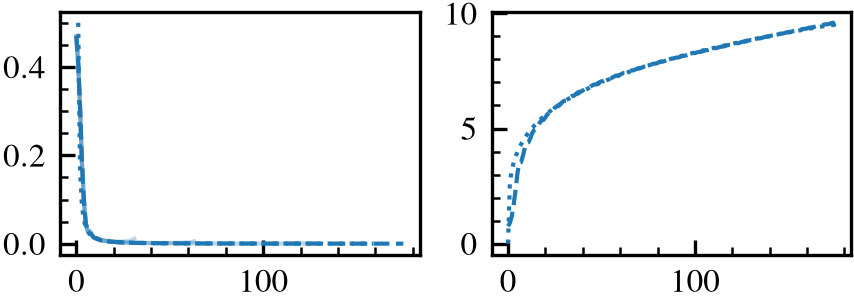

In [4]:
fig, ax = plt.subplots(1,2)
fig_dims = ssh.set_size(fraction=1.0, subplots=(1,2))
fig.set_size_inches(fig_dims)
dVvals = [3.2, 3.3, 3.4, 3.55, ]
prefixes = np.array([0.5,0.5,0.5, 1])
for j, dVval in enumerate(dVvals):
    col = f'C{j}'
    seldf_i = select_dV(df_i, dVval, atol=1e-7)
    yqty_i = np.abs(seldf_i["electron_corr"].values[0])
    yqty_i = obs.denoise_rolling(yqty_i, window=4)
    if np.isclose(dVval, 3.55) or True:
        logyqty_i = -np.log(yqty_i)
        xvals = np.arange(len(logyqty_i))
        fs = slice(20, -10)
        m, logc = np.polyfit(np.log(xvals[fs]), np.log(logyqty_i[fs]), 1)
        print(f'm = {m}')
        ax[1].plot(np.exp(logc) * xvals**m, c=col, ls=':', label=f'slope = {m:.3f}')
    ax[0].plot(yqty_i, c=col, ls='--', alpha=1.0) if not seldf_i.empty else None
    ax[1].plot(logyqty_i, c=col, ls='--', alpha=1.0) if not seldf_i.empty else None
    for nval in (64, 128, 256,):
        label = r'$\Delta V\!\!\!\!= $' + f'{dVval:.2f}' if nval==256 else None
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        yqty = np.abs(seldf["electron_conn"].values[0])
        yqty = obs.denoise_rolling(yqty, window=4)
        logyqty = -np.log(yqty)
        ax[0].plot(yqty, c=col, alpha=0.3, label=label)
        if dVval < 3.55 and nval == 256: 
            xarr = np.arange(160)
            Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)
            powerlaw = -0.25 * (Kc + 1./Kc + Ks + 1./Ks)
            ax[0].plot(xarr, prefixes[j] * (xarr)**(powerlaw), ls=':')
        
# ax.set_ylabel(r'$\displaystyle\sum_{\sigma}\langle c^\dagger_\sigma(x)c^{\phantom\dagger}_\sigma(0)\rangle$')
ax[0].set_xlabel(r'$x$', labelpad=-2)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_xlabel(r'$x$', labelpad=-2)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_ylim(1e-9, None)

310


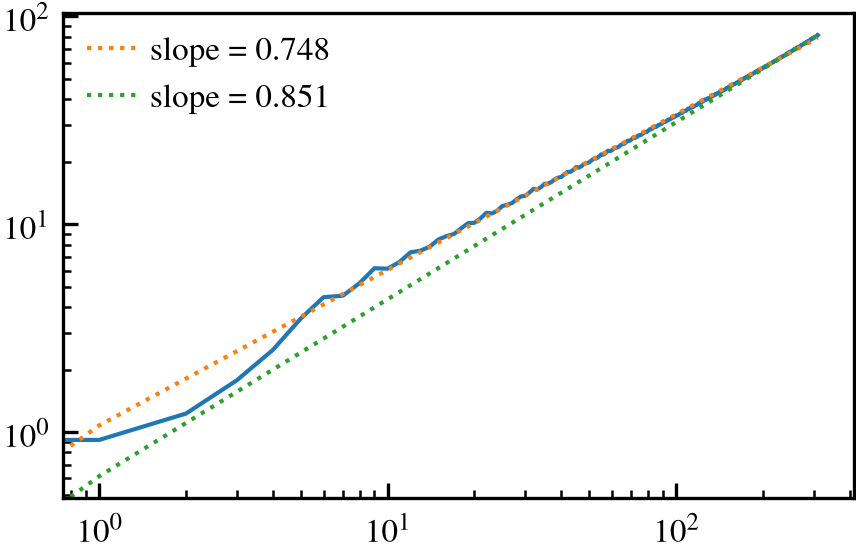

In [5]:
seldf_i = select_dV(df_i, 3.55, atol=1e-7)
yqty_i = np.abs(seldf_i["electron_corr"].values[0])
yqty_i = obs.denoise_rolling(yqty_i, window=4)
logyqty_i = -np.log(yqty_i)
xvals = np.arange(len(logyqty_i))

print(xvals[-1])
slopes = []
intercepts = []
for init in range(2, xvals[-16]):
    fs = slice(init, xvals[-1])
    m, logc = np.polyfit(np.log(xvals[fs]), np.log(logyqty_i[fs]), 1)
    slopes.append(m)
    intercepts.append(logc)
slopes = np.array(slopes)
intercepts = np.array(intercepts)
slopes.min(), slopes.max(), slopes.mean(), np.sqrt(slopes.var())
minarg, maxarg = np.argmin(slopes), np.argmax(slopes)
plt.plot(xvals, logyqty_i)
plt.yscale('log')
plt.xscale('log')
slopes.min(), slopes.max(), slopes.mean(), np.sqrt(slopes.var())
logcmin, logcmax  = intercepts[minarg], intercepts[maxarg]
mmin, mmax = slopes[minarg], slopes[maxarg]
plt.plot(np.exp(logcmin) * xvals**mmin, ls=':', label=f'slope = {mmin:.3f}')
plt.plot(np.exp(logcmax) * xvals**mmax, ls=':', label=f'slope = {mmax:.3f}')
plt.legend()

# np.argmin(slopes), np.argmax(slopes)

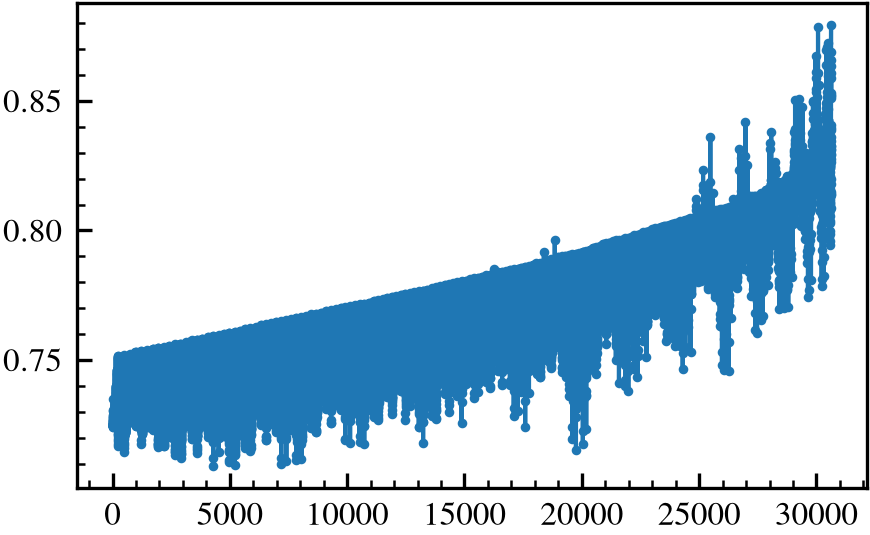

In [104]:
plt.plot(slopes, '.-')

290
0.7091755802801479 0.8794662724733473 0.7673005028470934 0.027016653662166733
Minimum slope: 0.7091755802801479 start: 38 stop: 53
Maximum slope: 0.8794662724733473 start: 264 stop: 279


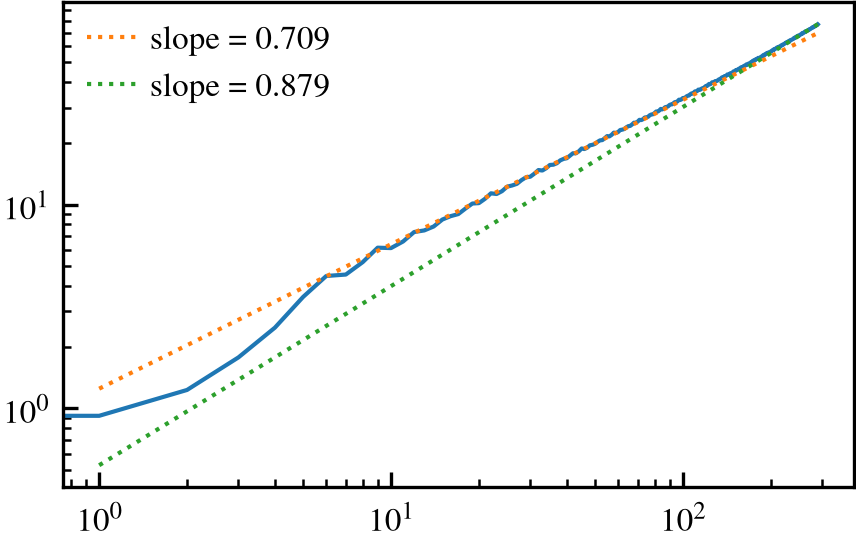

In [6]:
seldf_i = select_dV(df_i, 3.55, atol=1e-7)
yqty_i = np.abs(seldf_i["electron_corr"].values[0])[:-20]
yqty_i = obs.denoise_rolling(yqty_i, window=4)
logyqty_i = -np.log(yqty_i)
xvals = np.arange(len(logyqty_i))

print(xvals[-1])

slopes = []
intercepts = []
starts = []
stops = []

max_stop = len(xvals) - 10

for init in range(20, max_stop):
    for stop in range(init + 1, max_stop + 1):

        fs = slice(init, stop + 1)

        xfit = xvals[fs]
        yfit = logyqty_i[fs]

        valid = (
            (xfit > 0) &
            (yfit > 0) &
            np.isfinite(xfit) &
            np.isfinite(yfit)
        )

        xfit = xfit[valid]
        yfit = yfit[valid]

        if len(xfit) < 16:
            continue

        m, logc = np.polyfit(
            np.log(xfit),
            np.log(yfit),
            1
        )

        slopes.append(m)
        intercepts.append(logc)
        starts.append(init)
        stops.append(stop)

slopes = np.array(slopes)
intercepts = np.array(intercepts)
starts = np.array(starts)
stops = np.array(stops)

if len(slopes) == 0:
    raise ValueError("Not enough valid data points for a log-log fit.")

print(slopes.min(), slopes.max(), slopes.mean(), np.sqrt(slopes.var()))

minarg, maxarg = np.argmin(slopes), np.argmax(slopes)

print("Minimum slope:", slopes[minarg],
      "start:", starts[minarg],
      "stop:", stops[minarg])

print("Maximum slope:", slopes[maxarg],
      "start:", starts[maxarg],
      "stop:", stops[maxarg])

plt.plot(xvals, logyqty_i)
plt.yscale('log')
plt.xscale('log')

logcmin, logcmax = intercepts[minarg], intercepts[maxarg]
mmin, mmax = slopes[minarg], slopes[maxarg]

xplot = xvals[xvals > 0]

plt.plot(
    xplot,
    np.exp(logcmin) * xplot**mmin,
    ls=':',
    label=f'slope = {mmin:.3f}'
)

plt.plot(
    xplot,
    np.exp(logcmax) * xplot**mmax,
    ls=':',
    label=f'slope = {mmax:.3f}'
)

plt.legend()


/tmp/ipykernel_402932/1481756129.py:12: RuntimeWarning: divide by zero encountered in log
  m, c = np.polyfit(np.log(x_i)[fs], np.log(-np.log(sa_yi[fs])), 1)


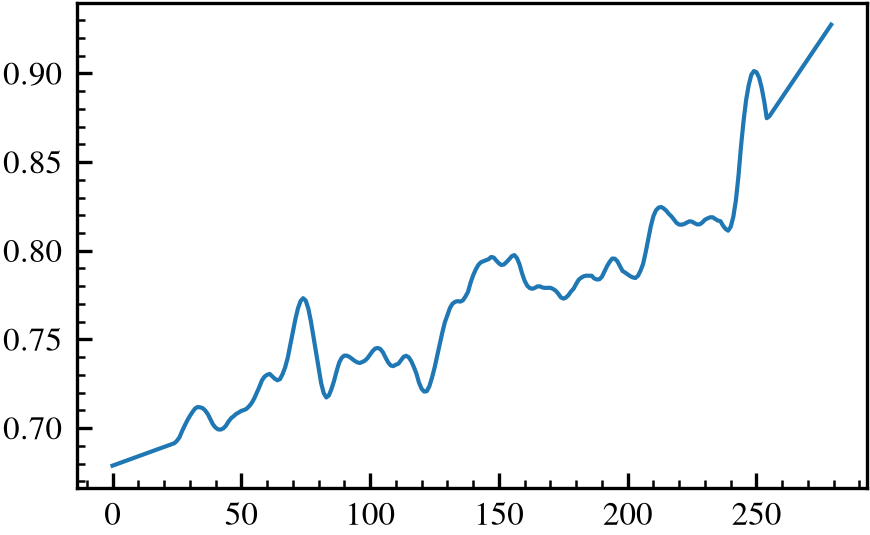

In [79]:
wsize = 8
slopes = []
intercepts = []
from scipy.signal import savgol_filter as sa
y_i = np.abs(seldf_i["electron_corr"].iloc[0])
x_i = np.arange(len(y_i))

# plt.plot(xvals, np.abs(np.log(yqty_i)))
for st in np.arange(20, 300):
    fs = slice(st, st+wsize)
    sa_yi = np.exp(-sa(-np.log(y_i), 20, 2))
    m, c = np.polyfit(np.log(x_i)[fs], np.log(-np.log(sa_yi[fs])), 1)
    slopes.append(m) 
    intercepts.append(c)

plt.plot(sa(slopes,50,1))
# plt.plot(x_i, np.abs(np.log(sa_yi)))
# plt.xscale('log')
# plt.yscale('log')
